In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.datasets import load_breast_cancer

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import TargetEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve

In [7]:
df = load_breast_cancer(as_frame=True).frame
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [8]:
X = df.drop(columns=['target'])
y = df['target']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
robust_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=42))
])
robust_pipeline

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [12]:
robust_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [15]:
print("--- Question 01: Robust Pipeline Execution Complete ---")
print(f"Training Set Shape : {X_train.shape}")
print(f"Testing Set Shape  : {X_test.shape}")
print(f"Model Training Accuracy: {robust_pipeline.score(X_train, y_train) * 100:.2f}%")
print(f"Model Testing Accuracy: {robust_pipeline.score(X_test, y_test) * 100:.2f}%")

--- Question 01: Robust Pipeline Execution Complete ---
Training Set Shape : (455, 30)
Testing Set Shape  : (114, 30)
Model Training Accuracy: 98.68%
Model Testing Accuracy: 95.61%


In [17]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

In [18]:
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

base_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced', 
        solver='saga', 
        max_iter=5000, 
        random_state=42
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("--- Question 02: GridSearchCV Hyperparameter Tuning Complete ---")
print("Best Parameters Found via CV:")
print(grid_search.best_params_)

best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)
final_f1 = f1_score(y_test, y_pred)

print(f"\nFinal F1-Score on the Hidden Test Set: {final_f1:.4f}")

--- Question 02: GridSearchCV Hyperparameter Tuning Complete ---
Best Parameters Found via CV:
{'model__C': 0.1, 'model__penalty': 'l2'}

Final F1-Score on the Hidden Test Set: 0.9718


In [19]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

wine_data = load_wine(as_frame=True)
X = wine_data.data
y = wine_data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

knn_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [20]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

df = load_breast_cancer(as_frame=True).frame

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

knn_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [22]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report


cancer_data = load_breast_cancer(as_frame=True)
X = cancer_data.data
y = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

numerical_features = X.columns.tolist()

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features)
    ]
)

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced', 
        solver='saga', 
        max_iter=5000, 
        random_state=42
    ))
])

log_param_grid = {
    'model__C': [0.1, 1.0, 10.0],
    'model__penalty': ['l1', 'l2']
}

log_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=log_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

log_grid_search.fit(X_train, y_train)

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

knn_param_grid = {
    'model__n_neighbors': [3, 5, 7],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

knn_grid_search.fit(X_train, y_train)

best_log_model = log_grid_search.best_estimator_
y_pred_log = best_log_model.predict(X_test)
f1_log = f1_score(y_test, y_pred_log)

best_knn_model = knn_grid_search.best_estimator_
y_pred_knn = best_knn_model.predict(X_test)
f1_knn = f1_score(y_test, y_pred_knn)

print("==================================================")
print("LOGISTIC REGRESSION OPTIMIZED REPORT")
print("==================================================")
print(f"Best Parameters: {log_grid_search.best_params_}")
print(classification_report(y_test, y_pred_log))

print("\n==================================================")
print("K-NEAREST NEIGHBORS OPTIMIZED REPORT")
print("==================================================")
print(f"Best Parameters: {knn_grid_search.best_params_}")
print(classification_report(y_test, y_pred_knn))

print("\n==================================================")
print("FINAL COMPARISON RESULTS")
print("==================================================")
print(f"Logistic Regression Final F1-Score : {f1_log:.4f}")
print(f"K-Nearest Neighbors Final F1-Score : {f1_knn:.4f}")

if f1_log > f1_knn:
    print("\nWINNER: Logistic Regression Model!")
elif f1_knn > f1_log:
    print("\nWINNER: K-Nearest Neighbors Model!")
else:
    print("\nRESULT: It's a Tie!")

LOGISTIC REGRESSION OPTIMIZED REPORT
Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2'}
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114


K-NEAREST NEIGHBORS OPTIMIZED REPORT
Best Parameters: {'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'uniform'}
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


FINAL COMPARISON RESULTS
Logistic Regression Final F1-Score : 0.9718
K-Nearest Neighbors Final F1-Score : 0.9796

WINNER: K-

C:\Users\HP\AppData\Local\Temp\ipykernel_18052\1348410109.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Exited"], ax=axes[2], palette="pastel")


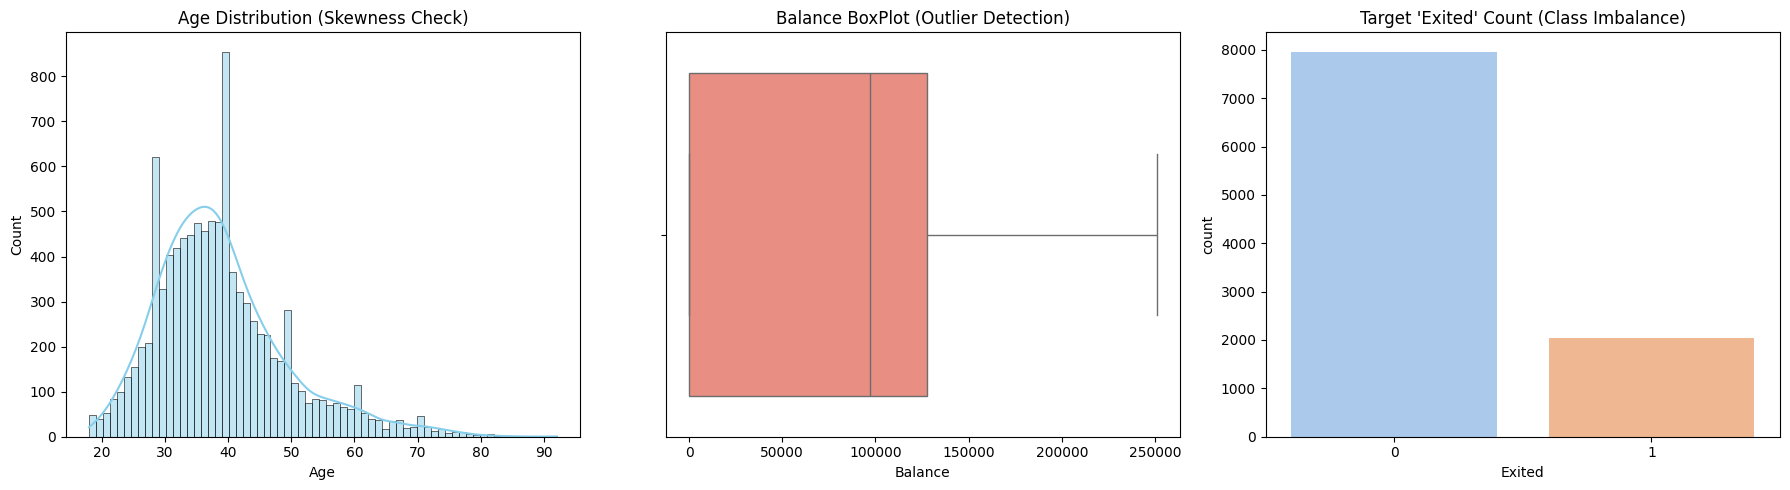

🎯 PHASE 5: FINAL INDUSTRIAL EVALUATION REPORT

[1] Logistic Regression (SGD) Best Params: {'model__eta0': 0.1, 'model__learning_rate': 'invscaling', 'model__penalty': 'l2'}
              precision    recall  f1-score   support

           0       0.93      0.75      0.83      1593
           1       0.44      0.76      0.56       407

    accuracy                           0.76      2000
   macro avg       0.68      0.76      0.70      2000
weighted avg       0.83      0.76      0.78      2000

--------------------------------------------------

[2] K-Nearest Neighbors Best Params: {'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'distance'}
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1593
           1       0.71      0.41      0.51       407

    accuracy                           0.84      2000
   macro avg       0.78      0.68      0.71      2000
weighted avg       0.83      0.84      0.83      2000

🏆 FINAL COMPE

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

file_path = r"F:\Jupyter Projects\Phitron AL ML\Dataset\Churn_Modelling.csv"
df = pd.read_csv(file_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["Age"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Age Distribution (Skewness Check)")

sns.boxplot(x=df["Balance"], ax=axes[1], color="salmon")
axes[1].set_title("Balance BoxPlot (Outlier Detection)")

sns.countplot(x=df["Exited"], ax=axes[2], palette="pastel")
axes[2].set_title("Target 'Exited' Count (Class Imbalance)")

plt.tight_layout()
plt.show()

X = df.drop(columns=["RowNumber", "CustomerId", "Surname", "Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "EstimatedSalary",
    "HasCrCard",
    "IsActiveMember",
]
categorical_features = ["Geography", "Gender", "NumOfProducts"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            SGDClassifier(
                loss="log_loss", class_weight="balanced", random_state=42
            ),
        ),
    ]
)

lr_param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__learning_rate": ["constant", "optimal", "invscaling"],
    "model__eta0": [0.01, 0.1],
}

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

knn_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", KNeighborsClassifier())]
)

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

lr_grid_search.fit(X_train, y_train)
knn_grid_search.fit(X_train, y_train)

best_lr_model = lr_grid_search.best_estimator_
best_knn_model = knn_grid_search.best_estimator_

y_pred_lr = best_lr_model.predict(X_test)
y_pred_knn = best_knn_model.predict(X_test)

f1_lr = f1_score(y_test, y_pred_lr)
f1_knn = f1_score(y_test, y_pred_knn)

print("==================================================")
print("🎯 PHASE 5: FINAL INDUSTRIAL EVALUATION REPORT")
print("==================================================")

print(
    f"\n[1] Logistic Regression (SGD) Best Params: {lr_grid_search.best_params_}"
)
print(classification_report(y_test, y_pred_lr))

print("-" * 50)

print(f"\n[2] K-Nearest Neighbors Best Params: {knn_grid_search.best_params_}")
print(classification_report(y_test, y_pred_knn))

print("==================================================")
print("🏆 FINAL COMPETITIVE VERDICT")
print("==================================================")
print(f"Optimized Logistic Regression F1-Score : {f1_lr:.4f}")
print(f"Optimized K-Nearest Neighbors F1-Score : {f1_knn:.4f}")

if f1_lr > f1_knn:
    print("\n⭐ ULTIMATE WINNER: Logistic Regression (SGD)!")
elif f1_knn > f1_lr:
    print("\n⭐ ULTIMATE WINNER: K-Nearest Neighbors (KNN)!")
else:
    print("\n⭐ RESULT: It's a dead tie!")
print("==================================================")